In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [27]:
df = pd.read_csv("../src/data/train/14.csv", parse_dates=["timestamp"])
df.head()

,timestamp,distance,temperature,co2,humidity,stage
0,2026-02-25 09:35:31,100,29.6,2877,68.2,0
1,2026-02-25 09:36:32,100,29.9,3538,72.3,0
2,2026-02-25 09:37:32,100,30.1,3645,73.1,0
3,2026-02-25 09:38:32,100,30.2,3606,73.5,0
4,2026-02-25 09:39:33,100,30.4,3432,73.9,0


In [5]:
df.describe()

,distance,temperature,co2,humidity,stage
count,340.000000,340.000000,340.000000,340.000000,340.000000
mean,81.076471,34.214706,14952.935294,68.952941,2.123529
std,6.900047,0.648635,11004.481225,3.156829,0.929382
min,70.000000,26.100000,1636.000000,61.700000,0.000000
25%,76.000000,34.200000,3197.750000,67.175000,1.000000
50%,80.000000,34.300000,13201.000000,69.100000,2.000000
75%,84.000000,34.400000,22546.750000,71.425000,3.000000
max,99.000000,34.500000,46674.000000,75.400000,3.000000


In [10]:
df.dtypes

timestamp      datetime64[ns]
distance                int64
temperature           float64
co2                     int64
humidity              float64
stage                   int64
dtype: object

In [8]:
df.columns

Index(['timestamp', 'distance', 'temperature', 'co2', 'humidity', 'stage'], dtype='object')

In [14]:
df.corr(method="spearman")

,timestamp,distance,temperature,co2,humidity,stage
timestamp,1.000000,-0.040085,0.831093,0.360043,0.863643,0.935631
distance,-0.040085,1.000000,-0.177632,-0.682122,-0.062462,-0.103374
temperature,0.831093,-0.177632,1.000000,0.573559,0.629312,0.896546
co2,0.360043,-0.682122,0.573559,1.000000,0.101579,0.466550
humidity,0.863643,-0.062462,0.629312,0.101579,1.000000,0.787505
stage,0.935631,-0.103374,0.896546,0.466550,0.787505,1.000000


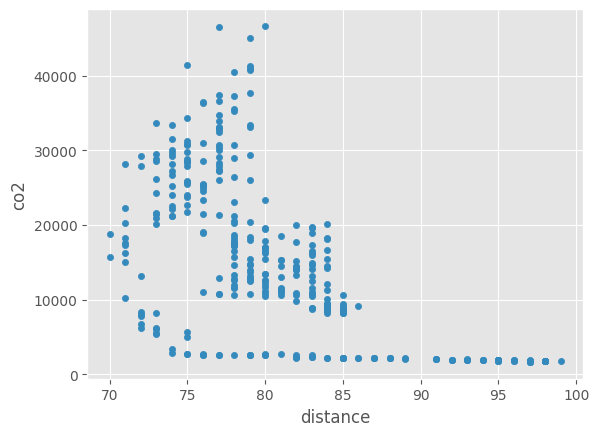

In [20]:
df.plot(kind="scatter", x="distance", y="co2")
plt.show()

<Axes: xlabel='distance', ylabel='co2'>

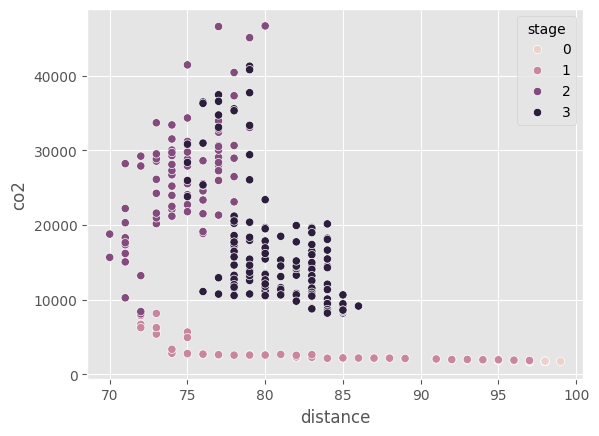

In [19]:
sns.scatterplot(data=df, x="distance", y="co2", hue="stage")

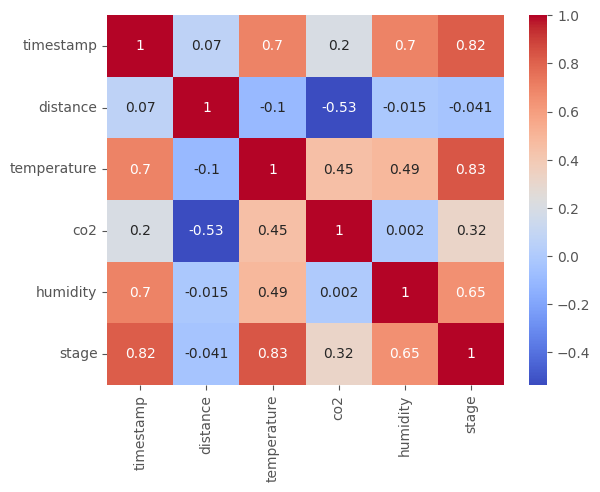

In [21]:
sns.heatmap(df.corr(method="kendall"), annot=True, cmap="coolwarm")
plt.show()

What is the average co2 during the different fermentation stages (4)?

In [30]:
stage_names={
    0: "Lag",
    1: "Rise",
    2: "Peak",
    3: "Fall",
}
results = []
for i in range(0, 4):
    result = df.query(f"stage == {i}")["co2"].mean()
    results.append(result)  
    print(f"Stage {i} ({stage_names[i]}): {result}")

Stage 0 (Lag): 2966.846153846154
Stage 1 (Rise): 3833.8082191780823
Stage 2 (Peak): 24973.06796116505
Stage 3 (Fall): 14015.914110429449


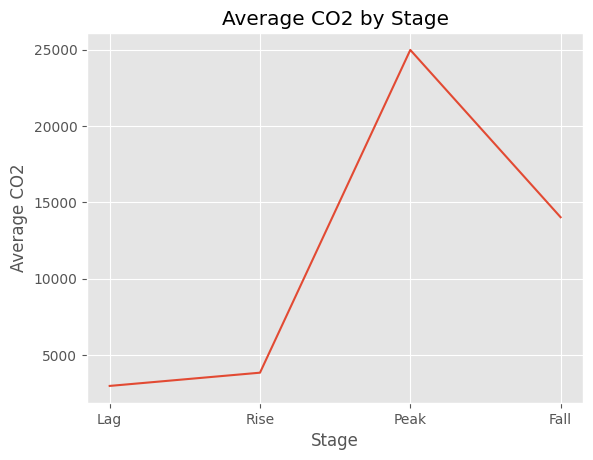

In [33]:
plt.plot(results)
plt.title("Average CO2 by Stage")
plt.xlabel("Stage")
plt.ylabel("Average CO2")
plt.xticks(ticks=range(4), labels=[stage_names[i] for i in range(4)])
plt.show()

What's the average of all properties at the different stages?

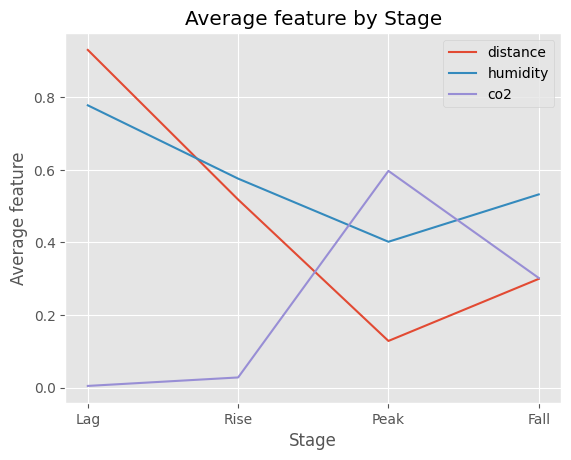

: 

In [ ]:
features = ["distance", "humidity", "co2"]
for feature in features:
    means = []
    # Normalize the feature
    df[feature] = (df[feature] - df[feature].min()) / (df[feature].max() - df[feature].min())
    for i in range(0, 4):
        mean = df.query(f"stage == {i}")[feature].mean()
        means.append(mean)
    plt.plot(means)

plt.title(f"Average feature by Stage")
plt.xlabel("Stage")
plt.ylabel(f"Average feature")
plt.xticks(ticks=range(4), labels=[stage_names[i] for i in range(4)])
plt.legend(features)
plt.show()